# **IEOR 164 Project Starter Code**

by GSI Gongyu Chen (gongyu@berkeley.edu)

# **Environment Setup**

In [1]:
# For Google Colab usage: Install the Pyomo package and a solver
import sys

if 'google.colab' in sys.modules:
    %pip install pyomo >/dev/null 2>/dev/null
    %pip install highspy >/dev/null 2>/dev/null

solver = 'appsi_highs'

import pyomo.environ as pyo
SOLVER = pyo.SolverFactory(solver)

assert SOLVER.available(), f"Solver {solver} is not available."

In [3]:
# Import all packages here
from pathlib import Path
import math
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo

In [4]:
# ============================================================
# Configuration
# ============================================================

CSV_PATH = "routerbench.csv"
OUTPUT_DIR = Path("starter_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Sweep values for weighted-sum objective:
# minimize avg_cost - alpha * avg_score
ALPHA_GRID = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]

# Optional random seed not currently needed, but kept for extension.
RANDOM_SEED = 42

In [13]:
df = pd.read_csv("routerbench.csv")
df["model"].nunique()
df["prompt_id"].nunique()
df["dataset"].value_counts()
df.groupby("model")[["score", "cost"]].mean().sort_values("score", ascending=False)

,score,cost
model,,
gpt-5,0.887500,0.042548
qwen3-235b-a22b-thinking-2507,0.845833,0.014699
deepseek-r1-0528,0.841667,0.021899
gemini-2.5-pro,0.829167,0.108404
gpt-5-chat,0.741667,0.004704
kimi-k2-0905,0.737500,0.004329
glm-4.6,0.737500,0.019497
qwen3-235b-a22b-2507,0.729167,0.001756
deepseek-v3.1-terminus,0.705556,0.001615


In [1]:
# ============================================================
# Utility functions
# ============================================================

def choose_solver():
    """
    Add your installed solver here.
    """
    candidate_solvers = ["appsi_highs"]
    for name in candidate_solvers:
        try:
            solver = pyo.SolverFactory(name)
            if solver is not None and solver.available(False):
                print(f"Using solver: {name}")
                return solver
        except Exception:
            pass
    raise RuntimeError(
        "No MILP solver found. Install HiGHS via `pip install highspy`, "
        "or install CBC/GLPK and make sure it is available to Pyomo."
    )


def safe_float(x, default=0.0):
    try:
        if pd.isna(x):
            return default
        return float(x)
    except Exception:
        return default

# **Data loading and preprocessing**

In [15]:
def load_routerbench_data(csv_path: str) -> pd.DataFrame:
    """
    Load the consolidated prompt-model dataset.

    Each row corresponds to a single prompt-model pair.

    Explanation of column fields:
      dataset: name of the benchmark dataset the prompt is sampled from.

      prompt_id: unique identifier of the prompt in the original benchmark.

      model: name of the model used to evaluate the prompt.

      score: binary performance score of the model on the prompt (0 or 1).

      cost: cost of evaluating the prompt (in dollar); if cost is zero, it means the model is open-source and can be evaluated locally without a cost-generating API call.
    """
    df = pd.read_csv(csv_path)

    required_cols = [
        "dataset", "prompt_id", "model", "score", "cost"
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"CSV is missing required columns: {missing}")

    # Normalize types
    df["dataset"] = df["dataset"].astype(str)
    df["prompt_id"] = df["prompt_id"].astype(str)
    df["model"] = df["model"].astype(str)
    df["score"] = pd.to_numeric(df["score"], errors="coerce").fillna(0.0)
    df["cost"] = pd.to_numeric(df["cost"], errors="coerce").fillna(0.0)

    # Keep one row per (prompt_id, model)
    dupes = df.duplicated(subset=["prompt_id", "model"])
    if dupes.any():
        print(
            f"Warning: found {dupes.sum()} duplicated (prompt_id, model) rows. "
            "Keeping the first occurrence."
        )
        df = df.drop_duplicates(subset=["prompt_id", "model"], keep="first").copy()

    return df


def build_prompt_weights(df: pd.DataFrame, equal_benchmark_weights: bool = True):
    """
    Construct prompt weights w_p for sample average approximation (SAA).

    By default, this function gets each prompt equal weight globally.

    You may modify this function to reflect a desired prompt distribution.
    """
    prompt_dataset = (
        df[["prompt_id", "dataset"]]
        .drop_duplicates()
        .set_index("prompt_id")["dataset"]
        .to_dict()
    )

    prompts = sorted(prompt_dataset.keys())
    datasets = sorted(set(prompt_dataset.values()))

    w = {p: 1.0 / len(prompts) for p in prompts}
    return w


def make_parameter_dicts(df: pd.DataFrame):
    """
    Create dictionaries score[(p,m)] and cost[(p,m)] for Pyomo.
    Assumes one row per (prompt_id, model).
    """
    score = {}
    cost = {}
    dataset_of_prompt = {}

    for _, row in df.iterrows():
        p = row["prompt_id"]
        m = row["model"]
        d = row["dataset"]
        score[(p, m)] = safe_float(row["score"], 0.0)
        cost[(p, m)] = safe_float(row["cost"], 0.0)
        dataset_of_prompt[p] = d

    prompts = sorted(df["prompt_id"].unique().tolist())
    models = sorted(df["model"].unique().tolist())
    datasets = sorted(df["dataset"].unique().tolist())

    return prompts, models, datasets, score, cost, dataset_of_prompt

# **Example Pyomo routing model**

In [16]:
def solve_weighted_sum_router(df: pd.DataFrame, alpha: float, prompt_weights: dict):
    """
    Decision Variables:
        x[p,m] in {0,1}: whether prompt p is assigned to model m

    Solve:
        minimize sum_p w_p sum_m x[p,m] * cost[p,m]
                 - alpha * sum_p w_p sum_m x[p,m] * score[p,m]

    s.t.
        for each prompt p: sum_m x[p,m] = 1
        x[p,m] in {0,1}

    where:
        alpha: the weight to balance the two conflicting objectives;
        prompt_weights: w_p for each prompt for approximating the expected  stochastic objective

    Interpretation:
        Choose for each prompt the best model among all possible candidate models. The result shall be interpreted as the "oracle" routing policy that you generally do not hope to beat.

        Your model should be much more complex and incorporate multiple realistic constraints to better reflect business and research considerations.
    """
    prompts, models, datasets, score, cost, dataset_of_prompt = make_parameter_dicts(df)

    # Restrict feasible assignments to those present in data
    available_pairs = sorted(score.keys())

    model = pyo.ConcreteModel()

    model.P = pyo.Set(initialize=prompts)
    model.M = pyo.Set(initialize=models)
    model.PM = pyo.Set(initialize=available_pairs, dimen=2)

    model.w = pyo.Param(model.P, initialize=prompt_weights, within=pyo.NonNegativeReals)
    model.score = pyo.Param(model.PM, initialize=score, within=pyo.Reals)
    model.cost = pyo.Param(model.PM, initialize=cost, within=pyo.NonNegativeReals)

    model.x = pyo.Var(model.PM, within=pyo.Binary)

    def assignment_rule(mdl, p):
        feasible_models = [mm for (pp, mm) in mdl.PM if pp == p]
        return sum(mdl.x[p, mm] for mm in feasible_models) == 1

    model.assignment = pyo.Constraint(model.P, rule=assignment_rule)

    def objective_rule(mdl):
        avg_cost = sum(mdl.w[p] * mdl.cost[p, m] * mdl.x[p, m] for (p, m) in mdl.PM)
        avg_score = sum(mdl.w[p] * mdl.score[p, m] * mdl.x[p, m] for (p, m) in mdl.PM)
        return avg_cost - alpha * avg_score

    model.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

    solver = choose_solver()
    results = solver.solve(model, tee=False)

    # Extract chosen routes
    chosen_rows = []
    for (p, m) in model.PM:
        if pyo.value(model.x[p, m]) > 0.5:
            chosen_rows.append({
                "prompt_id": p,
                "model": m,
                "dataset": dataset_of_prompt[p],
                "weight": prompt_weights[p],
                "score": score[(p, m)],
                "cost": cost[(p, m)],
            })

    chosen_df = pd.DataFrame(chosen_rows).sort_values(["dataset", "prompt_id"]).reset_index(drop=True)

    avg_cost = float((chosen_df["weight"] * chosen_df["cost"]).sum())
    avg_score = float((chosen_df["weight"] * chosen_df["score"]).sum())
    objective_value = avg_cost - alpha * avg_score

    return {
        "alpha": alpha,
        "policy_name": "Oracle Routing",
        "avg_cost": avg_cost,
        "avg_score": avg_score,
        "objective_value": objective_value,
        "assignments": chosen_df,
        "solver_status": str(results.solver.status),
        "termination_condition": str(results.solver.termination_condition),
    }

In [17]:
# ============================================================
# Additional baseline policies

# These reflects the most naive policies that your optimal solution should  outperform.
# ============================================================

def evaluate_single_best(df: pd.DataFrame, alpha: float, prompt_weights: dict):
    """
    Choose one model for all prompts using the same decision metric {Cost - alph * Score}.
    """
    prompts, models, datasets, score, cost, dataset_of_prompt = make_parameter_dicts(df)

    rows = []
    for m in models:
        sub = df[df["model"] == m].copy()

        # Need coverage for every prompt
        covered_prompts = set(sub["prompt_id"])
        if covered_prompts != set(prompts):
            continue

        weighted_cost = 0.0
        weighted_score = 0.0
        for _, r in sub.iterrows():
            p = r["prompt_id"]
            weighted_cost += prompt_weights[p] * float(r["cost"])
            weighted_score += prompt_weights[p] * float(r["score"])

        obj = weighted_cost - alpha * weighted_score
        rows.append({
            "alpha": alpha,
            "model": m,
            "avg_cost": weighted_cost,
            "avg_score": weighted_score,
            "objective_value": obj,
        })

    if not rows:
        raise RuntimeError("No model covers all prompts for the Single Best baseline.")

    cand = pd.DataFrame(rows).sort_values("objective_value").reset_index(drop=True)
    best_model = cand.loc[0, "model"]
    best_cost = float(cand.loc[0, "avg_cost"])
    best_score = float(cand.loc[0, "avg_score"])
    best_obj = float(cand.loc[0, "objective_value"])

    assignment_df = df[df["model"] == best_model][["prompt_id", "dataset", "model", "score", "cost"]].copy()
    assignment_df["weight"] = assignment_df["prompt_id"].map(prompt_weights)

    return {
        "alpha": alpha,
        "policy_name": "Single Best",
        "selected_model": best_model,
        "avg_cost": best_cost,
        "avg_score": best_score,
        "objective_value": best_obj,
        "assignments": assignment_df.sort_values(["dataset", "prompt_id"]).reset_index(drop=True),
    }


def evaluate_single_best_per_benchmark(df: pd.DataFrame, alpha: float, prompt_weights: dict):
    """
    For each benchmark dataset, choose one model used for all prompts in that dataset.
    """
    prompts, models, datasets, score, cost, dataset_of_prompt = make_parameter_dicts(df)

    selected_models = {}
    assignment_rows = []

    for d in datasets:
        df_d = df[df["dataset"] == d].copy()
        prompts_d = sorted(df_d["prompt_id"].unique().tolist())

        rows = []
        for m in models:
            sub = df_d[df_d["model"] == m].copy()

            if set(sub["prompt_id"]) != set(prompts_d):
                continue

            weighted_cost = 0.0
            weighted_score = 0.0
            for _, r in sub.iterrows():
                p = r["prompt_id"]
                weighted_cost += prompt_weights[p] * float(r["cost"])
                weighted_score += prompt_weights[p] * float(r["score"])

            obj = weighted_cost - alpha * weighted_score
            rows.append({
                "dataset": d,
                "model": m,
                "avg_cost_dataset_contrib": weighted_cost,
                "avg_score_dataset_contrib": weighted_score,
                "objective_value_dataset_contrib": obj,
            })

        if not rows:
            raise RuntimeError(f"No model covers all prompts in dataset {d}.")

        cand = pd.DataFrame(rows).sort_values("objective_value_dataset_contrib").reset_index(drop=True)
        best_model = cand.loc[0, "model"]
        selected_models[d] = best_model

        chosen = df_d[df_d["model"] == best_model][["prompt_id", "dataset", "model", "score", "cost"]].copy()
        chosen["weight"] = chosen["prompt_id"].map(prompt_weights)
        assignment_rows.append(chosen)

    assignment_df = pd.concat(assignment_rows, ignore_index=True)
    avg_cost = float((assignment_df["weight"] * assignment_df["cost"]).sum())
    avg_score = float((assignment_df["weight"] * assignment_df["score"]).sum())
    obj = avg_cost - alpha * avg_score

    return {
        "alpha": alpha,
        "policy_name": "Single Best per Benchmark",
        "selected_models_by_dataset": selected_models,
        "avg_cost": avg_cost,
        "avg_score": avg_score,
        "objective_value": obj,
        "assignments": assignment_df.sort_values(["dataset", "prompt_id"]).reset_index(drop=True),
    }

# **Plotting Functionality**

In [18]:
def plot_frontier(results_df: pd.DataFrame, output_path: Path):
    """
    Scatter/line plot on the cost-performance plane.
    x-axis: average cost (weighted by prompt-weights)
    y-axis: average score (weighted by prompt-weights)
    """
    plt.figure(figsize=(10, 7))

    # Oracle weighted-sum routing frontier
    opt = results_df[results_df["policy_name"] == "Oracle Routing"].sort_values("alpha")
    plt.plot(opt["avg_cost"], opt["avg_score"], marker="o", linewidth=2, label="Oracle Routing")

    # for _, row in opt.iterrows():
    #     plt.annotate(
    #         f"a={row['alpha']}",
    #         (row["avg_cost"], row["avg_score"]),
    #         textcoords="offset points",
    #         xytext=(5, 5),
    #         fontsize=8
    #     )

    # Single Best baseline
    sb = results_df[results_df["policy_name"] == "Single Best"].sort_values("alpha")
    plt.plot(sb["avg_cost"], sb["avg_score"], marker="s", linestyle="--", linewidth=1.5, label="Single Best")

    # Single Best per Benchmark baseline
    sbb = results_df[results_df["policy_name"] == "Single Best per Benchmark"].sort_values("alpha")
    plt.plot(
        sbb["avg_cost"], sbb["avg_score"],
        marker="^", linestyle="--", linewidth=1.5,
        label="Single Best per Benchmark"
    )

    '''
    ADD YOUR SOLUTION HERE TO BE PLOTTED ON THE SAME GRAPH
    '''

    plt.xlabel("Weighted Average Cost")
    plt.ylabel("Weighted Average Performance (Score)")
    plt.title("Routing Policies on the Cost-Performance Plane")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()

# **Your Implementation**

Implement your model here.

# My Optimization Model: Limited Model Pool with Budget Constraint


Answer the buisness questuon 1 :How does model pool size affect routing performance under a budget constraint?



Report of the result:
The budget level B=0.001 represents a strict average per-prompt cost constraint. In the dataset, high-end frontier models such as Gemini-2.5-Pro and GPT-5 have average costs of 0.108 and 0.043, respectively, which are much higher than the imposed budget. Therefore, the optimizer cannot rely heavily on these expensive models. Instead, it must route most prompts to low-cost or zero-cost models, while selectively using stronger models only when their marginal performance gain justifies the additional cost.

B=0.001 是一個嚴格的平均 prompt 成本限制。在資料中，Gemini-2.5-Pro 和 GPT-5 這類高階模型的平均成本分別是 0.108 和 0.043，遠高於我們設定的 budget。因此，最佳化模型不能大量使用這些昂貴模型，而是必須主要依賴低成本或零成本模型，並只在少數 prompt 上使用較強模型，以換取值得的 performance gain。

In [36]:
import pandas as pd
import pyomo.environ as pyo

def solve_one_pool_budget_model(df, K=3, budget=0.001):
    prompts = sorted(df["prompt_id"].unique())
    models = sorted(df["model"].unique())

    # Uniform prompt weights
    w = {p: 1 / len(prompts) for p in prompts}

    # Create dictionaries for Pyomo
    cost = {}
    score = {}
    dataset = {}

    for _, row in df.iterrows():
        p = row["prompt_id"]
        m = row["model"]

        cost[(p, m)] = row["cost"]
        score[(p, m)] = row["score"]
        dataset[p] = row["dataset"]

    model = pyo.ConcreteModel()

    model.P = pyo.Set(initialize=prompts)
    model.M = pyo.Set(initialize=models)

    # x[p,m] = 1 if prompt p is assigned to model m
    model.x = pyo.Var(model.P, model.M, domain=pyo.Binary)

    # y[m] = 1 if model m is selected in the model pool
    model.y = pyo.Var(model.M, domain=pyo.Binary)

    # Objective: maximize average score
    model.obj = pyo.Objective(
        expr=sum(
            w[p] * score.get((p, m), 0) * model.x[p, m]
            for p in prompts for m in models
        ),
        sense=pyo.maximize
    )

    # Each prompt must be assigned to exactly one model
    model.assign_one = pyo.Constraint(
        model.P,
        rule=lambda model, p: sum(model.x[p, m] for m in model.M) == 1
    )

    # A prompt can only be assigned to a selected model
    model.use_selected = pyo.Constraint(
        model.P, model.M,
        rule=lambda model, p, m: model.x[p, m] <= model.y[m]
    )

    # At most K models can be selected
    model.pool_size = pyo.Constraint(
        expr=sum(model.y[m] for m in model.M) <= K
    )

    # Average cost cannot exceed the budget
    model.budget_constraint = pyo.Constraint(
        expr=sum(
            w[p] * cost.get((p, m), 0) * model.x[p, m]
            for p in prompts for m in models
        ) <= budget
    )

    solver = pyo.SolverFactory("appsi_highs")
    solver_result = solver.solve(model)

    selected_models = [
        m for m in models
        if pyo.value(model.y[m]) > 0.5
    ]

    avg_score = pyo.value(model.obj)

    avg_cost = sum(
        w[p] * cost.get((p, m), 0) * pyo.value(model.x[p, m])
        for p in prompts for m in models
    )

    assignment_rows = []

    for p in prompts:
        for m in models:
            if pyo.value(model.x[p, m]) > 0.5:
                assignment_rows.append({
                    "prompt_id": p,
                    "dataset": dataset[p],
                    "model": m,
                    "score": score.get((p, m), 0),
                    "cost": cost.get((p, m), 0)
                })

    assignments = pd.DataFrame(assignment_rows)

    return {
        "K": K,
        "budget": budget,
        "avg_score": avg_score,
        "avg_cost": avg_cost,
        "selected_models": selected_models,
        "assignments": assignments,
        "model": model,
        "solver_result": solver_result
    }

In [37]:
def solve_pool_budget_models(df, K_values=[1, 2, 3, 5, 8, 10], budget=0.001):
    results = []

    for K in K_values:
        print(f"Solving model for K = {K}, budget = {budget}...")

        res = solve_one_pool_budget_model(
            df=df,
            K=K,
            budget=budget
        )

        results.append(res)

        print(
            f"  Done: avg_score={res['avg_score']:.6f}, "
            f"avg_cost={res['avg_cost']:.6f}, "
            f"selected={len(res['selected_models'])}"
        )

    return results

K_values = [1, 2, 3, 5, 8, 10]

results = solve_pool_budget_models(
    df=df,
    K_values=K_values,
    budget=0.001
)

Solving model for K = 1, budget = 0.001...
  Done: avg_score=0.616667, avg_cost=0.000000, selected=1
Solving model for K = 2, budget = 0.001...
  Done: avg_score=0.820833, avg_cost=0.000990, selected=2
Solving model for K = 3, budget = 0.001...
  Done: avg_score=0.883333, avg_cost=0.000999, selected=3
Solving model for K = 5, budget = 0.001...
  Done: avg_score=0.933333, avg_cost=0.000999, selected=5
Solving model for K = 8, budget = 0.001...
  Done: avg_score=0.966667, avg_cost=0.001000, selected=8
Solving model for K = 10, budget = 0.001...
  Done: avg_score=0.975000, avg_cost=0.000932, selected=10


In [38]:
def summarize_pool_budget_results(results):
    rows = []

    for r in results:
        rows.append({
            "K": r["K"],
            "budget": r["budget"],
            "avg_score": r["avg_score"],
            "avg_cost": r["avg_cost"],
            "num_selected_models": len(r["selected_models"]),
            "selected_models": ", ".join(r["selected_models"])
        })

    summary_df = pd.DataFrame(rows)
    summary_df = summary_df.sort_values("K").reset_index(drop=True)

    return summary_df

summary_df = summarize_pool_budget_results(results)

pd.set_option("display.max_colwidth", None)
summary_df

,K,budget,avg_score,avg_cost,num_selected_models,selected_models
0,1,0.001,0.616667,0.000000,1,MiniCPM4.1-8B
1,2,0.001,0.820833,0.000990,2,"MiniCPM4.1-8B, kimi-k2-0905"
2,3,0.001,0.883333,0.000999,3,"NVIDIA-Nemotron-Nano-9B-v2, deepseek-v3-0324, qwen3-235b-a22b-2507"
3,5,0.001,0.933333,0.000999,5,"Intern-S1-mini, Llama-3.1-8B-Instruct, NVIDIA-Nemotron-Nano-9B-v2, deepseek-v3-0324, qwen3-235b-a22b-2507"
4,8,0.001,0.966667,0.001000,8,"GLM-Z1-9B-0414, Intern-S1-mini, Llama-3.1-8B-Instruct, MiniCPM4.1-8B, deepseek-v3-0324, kimi-k2-0905, qwen3-235b-a22b-2507, qwen3-235b-a22b-thinking-2507"
5,10,0.001,0.975000,0.000932,10,"GLM-Z1-9B-0414, Intern-S1-mini, Llama-3.1-8B-Instruct, MiniCPM4.1-8B, NVIDIA-Nemotron-Nano-9B-v2, Qwen2.5-Coder-7B-Instruct, deepseek-v3.1-terminus, gemini-2.5-flash, qwen3-235b-a22b-2507, qwen3-235b-a22b-thinking-2507"


In [41]:
def get_model_usage_by_k(results):
    rows = []

    for r in results:
        K = r["K"]
        budget = r["budget"]
        assign = r["assignments"]

        usage = (
            assign
            .groupby("model")
            .agg(
                num_prompts=("prompt_id", "count"),
                avg_score=("score", "mean"),
                avg_cost=("cost", "mean"),
                total_cost=("cost", "sum"),
            )
            .reset_index()
        )

        usage["K"] = K
        usage["budget"] = budget
        usage["usage_share"] = usage["num_prompts"] / assign["prompt_id"].nunique()

        dataset_usage = (
            assign
            .groupby(["model", "dataset"])
            .size()
            .reset_index(name="dataset_num_prompts")
        )

        dataset_detail = (
            dataset_usage
            .groupby("model")
            .apply(
                lambda x: "; ".join(
                    f"{row.dataset}:{row.dataset_num_prompts}"
                    for row in x.itertuples()
                )
            )
            .reset_index(name="dataset_breakdown")
        )

        usage = usage.merge(dataset_detail, on="model", how="left")

        rows.append(usage)

    usage_df = pd.concat(rows, ignore_index=True)

    usage_df = usage_df.sort_values(
        ["K", "num_prompts", "avg_score"],
        ascending=[True, False, False]
    ).reset_index(drop=True)

    return usage_df

usage_df = get_model_usage_by_k(results)

usage_df

/var/folders/bl/q7nxsc917gqcw6nrrm6lnz3c0000gn/T/ipykernel_41345/114944673.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/var/folders/bl/q7nxsc917gqcw6nrrm6lnz3c0000gn/T/ipykernel_41345/114944673.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/var/folders/bl/q7nxsc917gqcw6nrrm6lnz3c0000gn/T/ipykernel_41345/114944673.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on t

,model,num_prompts,avg_score,avg_cost,total_cost,K,budget,usage_share,dataset_breakdown
0,MiniCPM4.1-8B,240,0.616667,0.000000,0.000000,1,0.001,1.000000,AIME:60; GPQA:60; LCB:60; MMLU-Pro:60
1,MiniCPM4.1-8B,168,0.875000,0.000000,0.000000,2,0.001,0.700000,AIME:52; GPQA:36; LCB:46; MMLU-Pro:34
2,kimi-k2-0905,72,0.694444,0.003300,0.237579,2,0.001,0.300000,AIME:8; GPQA:24; LCB:14; MMLU-Pro:26
3,qwen3-235b-a22b-2507,109,0.853211,0.000872,0.095040,3,0.001,0.454167,AIME:10; GPQA:39; LCB:33; MMLU-Pro:27
4,NVIDIA-Nemotron-Nano-9B-v2,89,0.966292,0.000939,0.083600,3,0.001,0.370833,AIME:36; GPQA:12; LCB:13; MMLU-Pro:28
5,deepseek-v3-0324,42,0.785714,0.001455,0.061108,3,0.001,0.175000,AIME:14; GPQA:9; LCB:14; MMLU-Pro:5
6,Llama-3.1-8B-Instruct,66,0.757576,0.000023,0.001512,5,0.001,0.275000,AIME:11; GPQA:20; LCB:13; MMLU-Pro:22
7,qwen3-235b-a22b-2507,54,1.000000,0.001412,0.076249,5,0.001,0.225000,AIME:8; GPQA:13; LCB:18; MMLU-Pro:15
8,NVIDIA-Nemotron-Nano-9B-v2,44,1.000000,0.001223,0.053822,5,0.001,0.183333,AIME:15; GPQA:4; LCB:15; MMLU-Pro:10
9,deepseek-v3-0324,40,1.000000,0.001301,0.052027,5,0.001,0.166667,AIME:7; GPQA:13; LCB:11; MMLU-Pro:9


In [27]:
df

,row_id,dataset,prompt_id,index,model,score,cost,prompt_tokens,completion_tokens
0,AIME_1|GLM-Z1-9B-0414,AIME,AIME_1,1,GLM-Z1-9B-0414,1,0.000000,215,3014
1,AIME_1|MiniCPM4.1-8B,AIME,AIME_1,1,MiniCPM4.1-8B,1,0.000000,230,7800
2,AIME_1|OpenThinker3-7B,AIME,AIME_1,1,OpenThinker3-7B,1,0.000000,235,7019
3,AIME_1|Llama-3.1-Nemotron-Nano-8B-v1,AIME,AIME_1,1,Llama-3.1-Nemotron-Nano-8B-v1,1,0.000066,221,3110
4,AIME_1|DeepSeek-R1-Distill-Qwen-7B,AIME,AIME_1,1,DeepSeek-R1-Distill-Qwen-7B,1,0.000350,211,3414
...,...,...,...,...,...,...,...,...,...
7855,MMLU-Pro_1001|GLM-Z1-9B-0414,MMLU-Pro,MMLU-Pro_1001,1001,GLM-Z1-9B-0414,0,0.000000,322,32446
7856,MMLU-Pro_1001|MiMo-7B-RL-0530,MMLU-Pro,MMLU-Pro_1001,1001,MiMo-7B-RL-0530,0,0.000000,338,2048
7857,MMLU-Pro_1001|OpenThinker3-7B,MMLU-Pro,MMLU-Pro_1001,1001,OpenThinker3-7B,0,0.000000,342,10432
7858,MMLU-Pro_1001|Llama-3.1-Nemotron-Nano-8B-v1,MMLU-Pro,MMLU-Pro_1001,1001,Llama-3.1-Nemotron-Nano-8B-v1,0,0.000162,328,7864


In [28]:
df["cost"].describe()

count    7860.000000
mean        0.008105
std         0.028110
min         0.000000
25%         0.000000
50%         0.000342
75%         0.003582
max         0.480387
Name: cost, dtype: float64

In [29]:
df.groupby("model")["cost"].mean().sort_values(ascending=False).head(10)

model
gemini-2.5-pro                   0.108404
gpt-5                            0.042548
deepseek-r1-0528                 0.021899
glm-4.6                          0.019497
gemini-2.5-flash                 0.015802
claude-sonnet-4                  0.015043
qwen3-235b-a22b-thinking-2507    0.014699
intern-s1                        0.005100
gpt-5-chat                       0.004704
kimi-k2-0905                     0.004329
Name: cost, dtype: float64

In [30]:
df.groupby("model")[["score", "cost"]].mean().sort_values("cost", ascending=False).head(15)

,score,cost
model,,
gemini-2.5-pro,0.829167,0.108404
gpt-5,0.887500,0.042548
deepseek-r1-0528,0.841667,0.021899
glm-4.6,0.737500,0.019497
gemini-2.5-flash,0.700000,0.015802
claude-sonnet-4,0.620833,0.015043
qwen3-235b-a22b-thinking-2507,0.845833,0.014699
intern-s1,0.629167,0.005100
gpt-5-chat,0.741667,0.004704


# **Experiments**

Loading data...

Basic dataset summary
--------------------------------------------------
Rows: 7,860
Unique prompts: 240
Unique models: 33

Prompts by dataset:
dataset
AIME        60
GPQA        60
LCB         60
MMLU-Pro    60
Name: count, dtype: int64

Weighting scheme
--------------------------------------------------
Total prompt weight = 1.000000

Solving for alpha = 0.01
Using solver: appsi_highs
  Oracle Routing            -> cost=0.000163, score=0.958333
  Single Best                -> cost=0.000000, score=0.616667, model=MiniCPM4.1-8B
  Single Best per Benchmark  -> cost=0.000665, score=0.750000

Solving for alpha = 0.05
Using solver: appsi_highs
  Oracle Routing            -> cost=0.000595, score=0.970833
  Single Best                -> cost=0.001756, score=0.729167, model=qwen3-235b-a22b-2507
  Single Best per Benchmark  -> cost=0.001733, score=0.816667

Solving for alpha = 0.1
Using solver: appsi_highs
  Oracle Routing            -> cost=0.001222, score=0.979167
  Single B

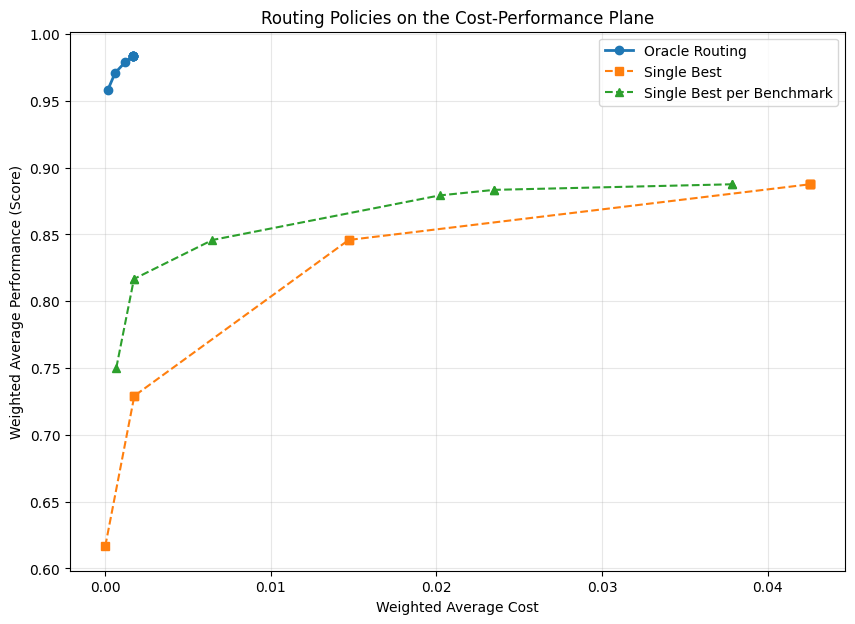


Saved outputs:
  starter_outputs/policy_summary.csv
  starter_outputs/cost_performance_frontier.png
  starter_outputs


In [10]:
def main():
    print("Loading data...")
    df = load_routerbench_data(CSV_PATH)

    print("\nBasic dataset summary")
    print("-" * 50)
    print(f"Rows: {len(df):,}")
    print(f"Unique prompts: {df['prompt_id'].nunique():,}")
    print(f"Unique models: {df['model'].nunique():,}")
    print("\nPrompts by dataset:")
    print(df[["prompt_id", "dataset"]].drop_duplicates()["dataset"].value_counts().sort_index())

    prompt_weights = build_prompt_weights(df)

    print("\nWeighting scheme")
    print("-" * 50)
    print(f"Total prompt weight = {sum(prompt_weights.values()):.6f}")

    policy_records = []
    example_assignment_saved = False

    # The oracle router and the baseline policies are defined over a range of alpha
    for alpha in ALPHA_GRID:
        print(f"\nSolving for alpha = {alpha}")

        # 1) Oracle routing
        optimal_result = solve_weighted_sum_router(df, alpha, prompt_weights)
        policy_records.append({
            "alpha": alpha,
            "policy_name": optimal_result["policy_name"],
            "avg_cost": optimal_result["avg_cost"],
            "avg_score": optimal_result["avg_score"],
            "objective_value": optimal_result["objective_value"],
            "details": "",
        })

        # Save one sample assignment table
        if not example_assignment_saved:
            assignment_path = OUTPUT_DIR / f"optimal_assignments_alpha_{str(alpha).replace('.', '_')}.csv"
            optimal_result["assignments"].to_csv(assignment_path, index=False)
            example_assignment_saved = True

        # 2) Single Best baseline
        sb_result = evaluate_single_best(df, alpha, prompt_weights)
        policy_records.append({
            "alpha": alpha,
            "policy_name": sb_result["policy_name"],
            "avg_cost": sb_result["avg_cost"],
            "avg_score": sb_result["avg_score"],
            "objective_value": sb_result["objective_value"],
            "details": f"model={sb_result['selected_model']}",
        })

        # 3) Single Best per Benchmark baseline
        sbb_result = evaluate_single_best_per_benchmark(df, alpha, prompt_weights)
        selected_str = "; ".join([f"{d}:{m}" for d, m in sorted(sbb_result["selected_models_by_dataset"].items())])
        policy_records.append({
            "alpha": alpha,
            "policy_name": sbb_result["policy_name"],
            "avg_cost": sbb_result["avg_cost"],
            "avg_score": sbb_result["avg_score"],
            "objective_value": sbb_result["objective_value"],
            "details": selected_str,
        })

        print(
            f"  Oracle Routing            -> cost={optimal_result['avg_cost']:.6f}, "
            f"score={optimal_result['avg_score']:.6f}"
        )
        print(
            f"  Single Best                -> cost={sb_result['avg_cost']:.6f}, "
            f"score={sb_result['avg_score']:.6f}, model={sb_result['selected_model']}"
        )
        print(
            f"  Single Best per Benchmark  -> cost={sbb_result['avg_cost']:.6f}, "
            f"score={sbb_result['avg_score']:.6f}"
        )

    results_df = pd.DataFrame(policy_records)

    print("\nFinal policy table")
    print("-" * 50)
    print(results_df)

    summary_path = OUTPUT_DIR / "policy_summary.csv"
    results_df.to_csv(summary_path, index=False)

    plot_path = OUTPUT_DIR / "cost_performance_frontier.png"
    plot_frontier(results_df, plot_path)

    print("\nSaved outputs:")
    print(f"  {summary_path}")
    print(f"  {plot_path}")
    print(f"  {OUTPUT_DIR}")


if __name__ == "__main__":
    main()